# LumenY 6.1 — 03_bis: Big Move Model Training (ATR-Relative Targets)

**Goal:** Train a model that predicts when a big directional move is about to happen, and in which direction.

**Approach:**
- **Two models:** One for LONG big moves, one for SHORT big moves
- **Target:** Binary — did MFE exceed 1.5 × ATR_24?
- **Algorithm:** LightGBM binary classification with 5-fold CV early stopping
- **Features:** 112 features (64 microstructure + 48 contextual) from `features_6/`
- **Train/test split:** Train on data ≤ 2024-06-30, test on data after

**Key change from 6.0:** ATR-relative targets instead of fixed 30-pip threshold.
This makes the model regime-adaptive — it learns "big relative to current volatility" rather than an absolute pip number.

**Input:** `features_6/` parquet files (from notebook 01)
**Output:** `backend/models_6.1/` — trained models + full backtest results

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
import gc
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, average_precision_score,
    classification_report, log_loss
)

FEATURES_DIR = Path('../backend/data/features_6')
MODELS_DIR   = Path('../backend/models_6.1')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

ALL_PAIRS = [
    'EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY',
    'EURJPY', 'GBPJPY', 'EURGBP', 'EURAUD', 'AUDJPY', 'CADJPY', 'CHFJPY', 'AUDNZD'
]

PIP_SIZE = {
    'EURUSD': 0.0001, 'GBPUSD': 0.0001, 'AUDUSD': 0.0001, 'NZDUSD': 0.0001,
    'USDCAD': 0.0001, 'USDCHF': 0.0001, 'USDJPY': 0.01,
    'EURJPY': 0.01, 'GBPJPY': 0.01, 'EURGBP': 0.0001, 'EURAUD': 0.0001,
    'AUDJPY': 0.01, 'CADJPY': 0.01, 'CHFJPY': 0.01, 'AUDNZD': 0.0001,
}

# ATR-relative MFE threshold (replaces fixed 30 pips)
MFE_ATR_MULTIPLIER = 1.5

# Train/test split
TRAIN_END = '2024-06-30'

# CV config
N_CV_FOLDS = 5

print('Ready.')
print(f'MFE threshold: {MFE_ATR_MULTIPLIER}x ATR_24')
print(f'Train cutoff: {TRAIN_END}')
print(f'CV folds: {N_CV_FOLDS}')
print(f'Output: {MODELS_DIR}')

Ready.
MFE threshold: 1.5x ATR_24
Train cutoff: 2024-06-30
CV folds: 5
Output: ..\backend\models_6.1


## 1. Load Dataset

In [2]:
# Load all pairs
dfs = []
for pair in ALL_PAIRS:
    df = pd.read_parquet(FEATURES_DIR / f'{pair}_features.parquet')
    dfs.append(df)
    print(f'{pair}: {len(df):,} rows')

df_all = pd.concat(dfs)
del dfs

# Identify column groups
label_cols = ['mfe_long_pips', 'mfe_short_pips', 'trail_long_bars', 'trail_short_bars',
              'trail_stop_pips', 'mfe_atr_24']
feature_cols = [c for c in df_all.columns if c not in label_cols + ['pair']]

# ATR-relative targets (KEY CHANGE from 6.0)
atr_24 = df_all['atr_24'].clip(lower=1)
df_all['mfe_long_ratio'] = df_all['mfe_long_pips'] / atr_24
df_all['mfe_short_ratio'] = df_all['mfe_short_pips'] / atr_24
df_all['target_long'] = (df_all['mfe_long_ratio'] > MFE_ATR_MULTIPLIER).astype(np.float32)
df_all['target_short'] = (df_all['mfe_short_ratio'] > MFE_ATR_MULTIPLIER).astype(np.float32)

# Valid rows (have MFE labels)
valid_mask = df_all['mfe_long_pips'].notna()
df_valid = df_all[valid_mask].copy()

print(f'\nTotal: {len(df_valid):,} valid rows, {len(feature_cols)} features')
print(f'Date range: {df_valid.index.min().date()} to {df_valid.index.max().date()}')
print(f'Target positive rate — Long: {df_valid["target_long"].mean():.1%}, Short: {df_valid["target_short"].mean():.1%}')
print(f'\nATR_24 stats:')
print(df_valid['atr_24'].describe())

EURUSD: 100,675 rows
GBPUSD: 100,269 rows
AUDUSD: 101,011 rows
NZDUSD: 99,663 rows
USDCAD: 100,185 rows
USDCHF: 100,541 rows
USDJPY: 99,773 rows
EURJPY: 101,493 rows
GBPJPY: 101,425 rows
EURGBP: 100,757 rows
EURAUD: 100,929 rows
AUDJPY: 101,994 rows
CADJPY: 102,252 rows
CHFJPY: 100,835 rows
AUDNZD: 106,218 rows

Total: 1,471,525 valid rows, 112 features
Date range: 2009-09-25 to 2025-12-31
Target positive rate — Long: 31.2%, Short: 34.8%

ATR_24 stats:
count    1.470562e+06
mean     2.056580e+01
std      1.268031e+01
min      2.430000e+00
25%      1.355000e+01
50%      1.811500e+01
75%      2.451250e+01
max      8.592625e+02
Name: atr_24, dtype: float64


## 2. Train / Test Split

In [3]:
train_end = pd.Timestamp(TRAIN_END)

df_train = df_valid[df_valid.index <= train_end]
df_test  = df_valid[df_valid.index > train_end]

X_train = df_train[feature_cols].ffill().fillna(0)
X_test  = df_test[feature_cols].ffill().fillna(0)

print(f'Train: {len(df_train):,} rows ({df_train.index.min().date()} -> {df_train.index.max().date()})')
print(f'Test:  {len(df_test):,} rows ({df_test.index.min().date()} -> {df_test.index.max().date()})')
print(f'\nTrain target rate — Long: {df_train["target_long"].mean():.1%}, Short: {df_train["target_short"].mean():.1%}')
print(f'Test  target rate — Long: {df_test["target_long"].mean():.1%}, Short: {df_test["target_short"].mean():.1%}')

Train: 1,335,153 rows (2009-09-25 -> 2024-06-28)
Test:  136,372 rows (2024-07-01 -> 2025-12-31)

Train target rate — Long: 31.8%, Short: 34.3%
Test  target rate — Long: 25.8%, Short: 39.5%


## 3. LightGBM — 5-Fold CV to Find Optimal Iterations

Run CV on training data to find best n_estimators, then train final models.

In [4]:
lgbm_params = {
    'objective':         'binary',
    'metric':            'binary_logloss',
    'boosting_type':     'gbdt',
    'n_estimators':      5000,
    'learning_rate':     0.02,
    'num_leaves':        64,
    'max_depth':         6,
    'min_child_samples': 50,
    'feature_fraction':  0.7,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'is_unbalance':      True,
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
    'device':            'gpu',
}

print(f'LightGBM params ready. n_estimators=5000, early stopping via {N_CV_FOLDS}-fold CV')

LightGBM params ready. n_estimators=5000, early stopping via 5-fold CV


## 4. Train LONG + SHORT Models

In [5]:
from sklearn.model_selection import KFold

params = lgbm_params.copy()

# ═══════════════════════════════════════════════════════════════
# LONG MODEL — 5-fold CV
# ═══════════════════════════════════════════════════════════════
print('Training LONG big-move model...\n')

kf = KFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=42)
cv_logloss_long = []
cv_auc_long = []
best_iters_long = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr = df_train['target_long'].iloc[train_idx]
    y_val = df_train['target_long'].iloc[val_idx]
    
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    
    p_val = model.predict_proba(X_val)[:, 1]
    ll = log_loss(y_val, p_val)
    auc = roc_auc_score(y_val, p_val)
    
    cv_logloss_long.append(ll)
    cv_auc_long.append(auc)
    best_iters_long.append(model.best_iteration_)
    
    print(f'  Fold {fold+1}: logloss={ll:.4f}, AUC={auc:.4f}, iters={model.best_iteration_}')

print(f'\nCV Mean — logloss: {np.mean(cv_logloss_long):.4f}, AUC: {np.mean(cv_auc_long):.4f}')
print(f'Best iters: {best_iters_long}')

# Final LONG model: use max(100, avg_iters)
n_iters_long = max(100, int(np.mean(best_iters_long)))
final_params_long = params.copy()
final_params_long['n_estimators'] = n_iters_long
model_long = lgb.LGBMClassifier(**final_params_long)
model_long.fit(X_train, df_train['target_long'])
print(f'\nFinal LONG model trained: {n_iters_long} iters')

# ═══════════════════════════════════════════════════════════════
# SHORT MODEL — 5-fold CV
# ═══════════════════════════════════════════════════════════════
print('\n\nTraining SHORT big-move model...\n')

cv_logloss_short = []
cv_auc_short = []
best_iters_short = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr = df_train['target_short'].iloc[train_idx]
    y_val = df_train['target_short'].iloc[val_idx]
    
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    
    p_val = model.predict_proba(X_val)[:, 1]
    ll = log_loss(y_val, p_val)
    auc = roc_auc_score(y_val, p_val)
    
    cv_logloss_short.append(ll)
    cv_auc_short.append(auc)
    best_iters_short.append(model.best_iteration_)
    
    print(f'  Fold {fold+1}: logloss={ll:.4f}, AUC={auc:.4f}, iters={model.best_iteration_}')

print(f'\nCV Mean — logloss: {np.mean(cv_logloss_short):.4f}, AUC: {np.mean(cv_auc_short):.4f}')
print(f'Best iters: {best_iters_short}')

# Final SHORT model: use max(100, avg_iters)
n_iters_short = max(100, int(np.mean(best_iters_short)))
final_params_short = params.copy()
final_params_short['n_estimators'] = n_iters_short
model_short = lgb.LGBMClassifier(**final_params_short)
model_short.fit(X_train, df_train['target_short'])
print(f'\nFinal SHORT model trained: {n_iters_short} iters')

# ═══════════════════════════════════════════════════════════════
# Predict on test set
# ═══════════════════════════════════════════════════════════════
p_long = model_long.predict_proba(X_test)[:, 1]
p_short = model_short.predict_proba(X_test)[:, 1]

auc_long = roc_auc_score(df_test['target_long'], p_long)
auc_short = roc_auc_score(df_test['target_short'], p_short)

print(f'\n--- Test Set Results ---')
print(f'LONG  AUC: {auc_long:.4f}')
print(f'SHORT AUC: {auc_short:.4f}')

print(f'\nP(long) distribution:')
print(pd.Series(p_long, name='p_long').describe())
print(f'\nP(short) distribution:')
print(pd.Series(p_short, name='p_short').describe())

# Build results DataFrame
results = pd.DataFrame({
    'p_long': p_long,
    'p_short': p_short,
    'mfe_long_pips': df_test['mfe_long_pips'].values,
    'mfe_short_pips': df_test['mfe_short_pips'].values,
    'trail_long_bars': df_test['trail_long_bars'].values,
    'trail_short_bars': df_test['trail_short_bars'].values,
    'trail_stop_pips': df_test['trail_stop_pips'].values,
    'target_long': df_test['target_long'].values,
    'target_short': df_test['target_short'].values,
    'pair': df_test['pair'].values,
}, index=X_test.index)

results['best_dir'] = np.where(results['p_long'] >= results['p_short'], 'long', 'short')
results['best_prob'] = np.maximum(results['p_long'], results['p_short'])
results['mfe_pred_dir'] = np.where(
    results['best_dir'] == 'long',
    results['mfe_long_pips'],
    results['mfe_short_pips']
)

print(f'\nTotal predictions: {len(results):,}')
print(f'Date range: {results.index.min().date()} -> {results.index.max().date()}')

Training LONG big-move model...

  Fold 1: logloss=0.6240, AUC=0.5547, iters=4
  Fold 2: logloss=0.6248, AUC=0.5537, iters=5
  Fold 3: logloss=0.6251, AUC=0.5542, iters=5
  Fold 4: logloss=0.6233, AUC=0.5548, iters=4
  Fold 5: logloss=0.6250, AUC=0.5576, iters=5

CV Mean — logloss: 0.6244, AUC: 0.5550
Best iters: [4, 5, 5, 4, 5]

Final LONG model trained: 100 iters


Training SHORT big-move model...

  Fold 1: logloss=0.6430, AUC=0.5474, iters=5
  Fold 2: logloss=0.6424, AUC=0.5504, iters=5
  Fold 3: logloss=0.6430, AUC=0.5521, iters=5
  Fold 4: logloss=0.6430, AUC=0.5521, iters=5
  Fold 5: logloss=0.6419, AUC=0.5512, iters=5

CV Mean — logloss: 0.6426, AUC: 0.5506
Best iters: [5, 5, 5, 5, 5]

Final SHORT model trained: 100 iters

--- Test Set Results ---
LONG  AUC: 0.6101
SHORT AUC: 0.5924

P(long) distribution:
count    136372.000000
mean          0.409187
std           0.082869
min           0.106729
25%           0.370569
50%           0.433815
75%           0.466913
max           

## 5. Precision-Recall Analysis

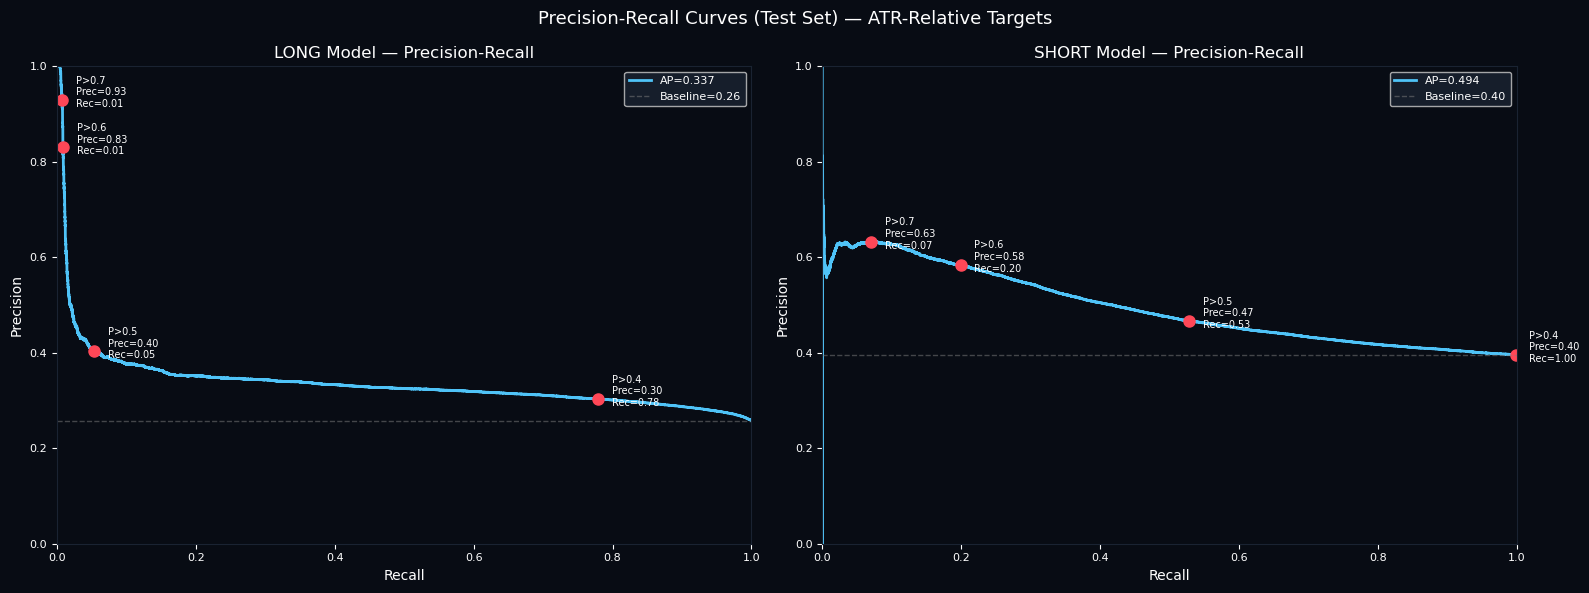

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#080c14')

for ax, (direction, p_col, t_col) in zip(axes, [
    ('LONG', 'p_long', 'target_long'),
    ('SHORT', 'p_short', 'target_short')
]):
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
    
    precision, recall, thresholds = precision_recall_curve(results[t_col], results[p_col])
    ap = average_precision_score(results[t_col], results[p_col])
    
    ax.plot(recall, precision, color='#4fc3f7', linewidth=2, label=f'AP={ap:.3f}')
    
    # Mark key thresholds
    for thresh in [0.4, 0.5, 0.6, 0.7]:
        idx = np.searchsorted(thresholds, thresh)
        if idx < len(precision):
            ax.plot(recall[idx], precision[idx], 'o', color='#ff4757', markersize=8)
            ax.annotate(f'P>{thresh:.1f}\nPrec={precision[idx]:.2f}\nRec={recall[idx]:.2f}',
                       (recall[idx], precision[idx]), textcoords='offset points',
                       xytext=(10, -5), color='white', fontsize=7)
    
    baseline = results[t_col].mean()
    ax.axhline(baseline, color='gray', linewidth=1, linestyle='--', alpha=0.5, label=f'Baseline={baseline:.2f}')
    
    ax.set_xlabel('Recall', color='white')
    ax.set_ylabel('Precision', color='white')
    ax.set_title(f'{direction} Model — Precision-Recall', color='white')
    ax.legend(facecolor='#1a2332', labelcolor='white', fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle('Precision-Recall Curves (Test Set) — ATR-Relative Targets', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Realistic Backtest — Trailing Stop PnL

Backtest uses trailing stop logic with per-pair cooldown. PnL is in real pips.
Cooldown is per-pair only: a trade on EURUSD does NOT block trades on other pairs.

In [7]:
def backtest_trailing_stop(results_df, prob_threshold, cooldown_hours=4, spread_pips=2.8):
    """Backtest using trailing stop logic with per-pair cooldown.
    
    For each triggered bar:
    - Direction = best_dir (whichever model is more confident)
    - PnL = MFE in that direction minus trail stop distance minus spread
    - Cooldown is per-pair only: a trade on EURUSD does NOT block GBPJPY
    
    Returns DataFrame of trades.
    """
    mask = results_df['best_prob'] > prob_threshold
    candidates = results_df[mask].sort_index()
    
    trades = []
    pair_next_allowed = {}  # per-pair cooldown tracker
    
    for idx, row in candidates.iterrows():
        pair = row['pair']
        
        # Check per-pair cooldown
        if pair in pair_next_allowed and idx < pair_next_allowed[pair]:
            continue
        
        direction = row['best_dir']
        mfe = row['mfe_long_pips'] if direction == 'long' else row['mfe_short_pips']
        duration = row['trail_long_bars'] if direction == 'long' else row['trail_short_bars']
        stop = row['trail_stop_pips']
        
        if np.isnan(mfe) or np.isnan(stop):
            continue
        
        # Realized PnL from trailing stop = MFE - trail_stop - spread
        realized_pnl = mfe - stop - spread_pips
        
        trades.append({
            'entry_time': idx,
            'pair': pair,
            'direction': direction,
            'p_long': row['p_long'],
            'p_short': row['p_short'],
            'best_prob': row['best_prob'],
            'mfe_pips': mfe,
            'trail_stop_pips': stop,
            'realized_pnl': realized_pnl,
            'duration_hours': duration,
        })
        
        # Per-pair cooldown
        dur = duration if not np.isnan(duration) else cooldown_hours
        cooldown = max(cooldown_hours, dur)
        pair_next_allowed[pair] = idx + pd.Timedelta(hours=cooldown)
    
    if not trades:
        return pd.DataFrame()
    
    return pd.DataFrame(trades)


# Run backtest at different thresholds
print(f'{"Threshold":>10} {"Trades":>8} {"Win%":>8} {"AvgPnL":>10} {"TotalPnL":>12} {"AvgMFE":>10} {"Sharpe":>8}')
print('-' * 72)

backtest_results = {}

for thresh in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    trades = backtest_trailing_stop(results, thresh, cooldown_hours=4)
    if len(trades) < 10:
        continue
    
    wins = (trades['realized_pnl'] > 0).sum()
    win_rate = wins / len(trades)
    avg_pnl = trades['realized_pnl'].mean()
    total_pnl = trades['realized_pnl'].sum()
    avg_mfe = trades['mfe_pips'].mean()
    sharpe = (trades['realized_pnl'].mean() / trades['realized_pnl'].std()) * np.sqrt(252) if trades['realized_pnl'].std() > 0 else 0
    
    backtest_results[thresh] = trades
    flag = ' <<<' if avg_pnl > 0 else ''
    print(f'P > {thresh:.2f} {len(trades):>8} {win_rate:>7.1%} {avg_pnl:>9.1f}p {total_pnl:>11.1f}p {avg_mfe:>9.1f}p {sharpe:>8.2f}{flag}')

if not backtest_results:
    print('\nNo threshold produced >= 10 trades.')
    print(f'  Max best_prob in results: {results["best_prob"].max():.4f}')
    print(f'  best_prob distribution:')
    print(results['best_prob'].describe())

 Threshold   Trades     Win%     AvgPnL     TotalPnL     AvgMFE   Sharpe
------------------------------------------------------------------------
P > 0.20    20098   32.1%       2.8p     55273.8p      42.0p     0.52 <<<
P > 0.25    20098   32.1%       2.8p     55273.8p      42.0p     0.52 <<<
P > 0.30    20098   32.1%       2.8p     55273.8p      42.0p     0.52 <<<
P > 0.35    20098   32.1%       2.8p     55273.5p      42.0p     0.52 <<<
P > 0.40    20097   32.1%       2.7p     55231.1p      42.0p     0.52 <<<
P > 0.45    20074   32.1%       2.7p     53659.4p      41.9p     0.51 <<<
P > 0.50    13128   35.8%       8.9p    116535.3p      48.6p     1.43 <<<
P > 0.55     6543   43.2%      24.5p    160551.3p      65.2p     2.92 <<<
P > 0.60     4296   48.3%      34.8p    149436.1p      76.5p     3.74 <<<
P > 0.65     2926   53.4%      47.5p    138990.4p      90.7p     4.52 <<<
P > 0.70     1872   59.6%      65.0p    121730.5p     111.1p     5.43 <<<
P > 0.75      974   62.4%      91.6p    

## 7. Per-Pair Breakdown (Best Threshold)

In [8]:
if not backtest_results:
    print('No backtest results — skipping per-pair breakdown.')
    best_thresh = None
    best_trades = pd.DataFrame()
else:
    # Find best threshold by total PnL
    best_thresh = max(backtest_results.keys(), 
                      key=lambda t: backtest_results[t]['realized_pnl'].sum() if len(backtest_results[t]) >= 10 else -1e9)
    best_trades = backtest_results[best_thresh]

    print(f'Best threshold: P > {best_thresh:.2f} ({len(best_trades)} trades)\n')
    print(f'{"Pair":<10} {"Trades":>8} {"Win%":>8} {"AvgPnL":>10} {"TotalPnL":>12} {"AvgMFE":>10} {"Long%":>8}')
    print('-' * 70)

    for pair in sorted(best_trades['pair'].unique()):
        p = best_trades[best_trades['pair'] == pair]
        wins = (p['realized_pnl'] > 0).sum()
        wr = wins / len(p) if len(p) > 0 else 0
        long_pct = (p['direction'] == 'long').mean()
        flag = ' <<<' if p['realized_pnl'].mean() > 0 else ''
        print(f'{pair:<10} {len(p):>8} {wr:>7.1%} {p["realized_pnl"].mean():>9.1f}p {p["realized_pnl"].sum():>11.1f}p '
              f'{p["mfe_pips"].mean():>9.1f}p {long_pct:>7.1%}{flag}')

Best threshold: P > 0.55 (6543 trades)

Pair         Trades     Win%     AvgPnL     TotalPnL     AvgMFE    Long%
----------------------------------------------------------------------
AUDJPY          489   50.1%      21.1p     10319.9p      62.2p    5.7% <<<
AUDNZD          836   53.6%      35.7p     29881.4p      78.8p    3.6% <<<
AUDUSD          608   33.4%       2.3p      1377.7p      26.9p    2.0% <<<
CADJPY          493   51.3%      40.4p     19918.6p      84.0p    5.3% <<<
CHFJPY          756   47.1%      53.6p     40510.3p     123.0p    3.7% <<<
EURAUD          632   45.7%      27.0p     17089.4p      77.7p    3.5% <<<
EURGBP          681   39.9%      11.3p      7712.6p      35.6p    5.1% <<<
EURJPY          310   33.2%       0.2p        57.9p      49.5p    1.6% <<<
EURUSD           99   34.3%       3.4p       338.6p      28.0p    6.1% <<<
GBPJPY          216   36.6%      -5.7p     -1234.3p      55.2p    1.4%
GBPUSD           81   34.6%       9.1p       738.4p      39.4p    6.2%

## 8. Equity Curves

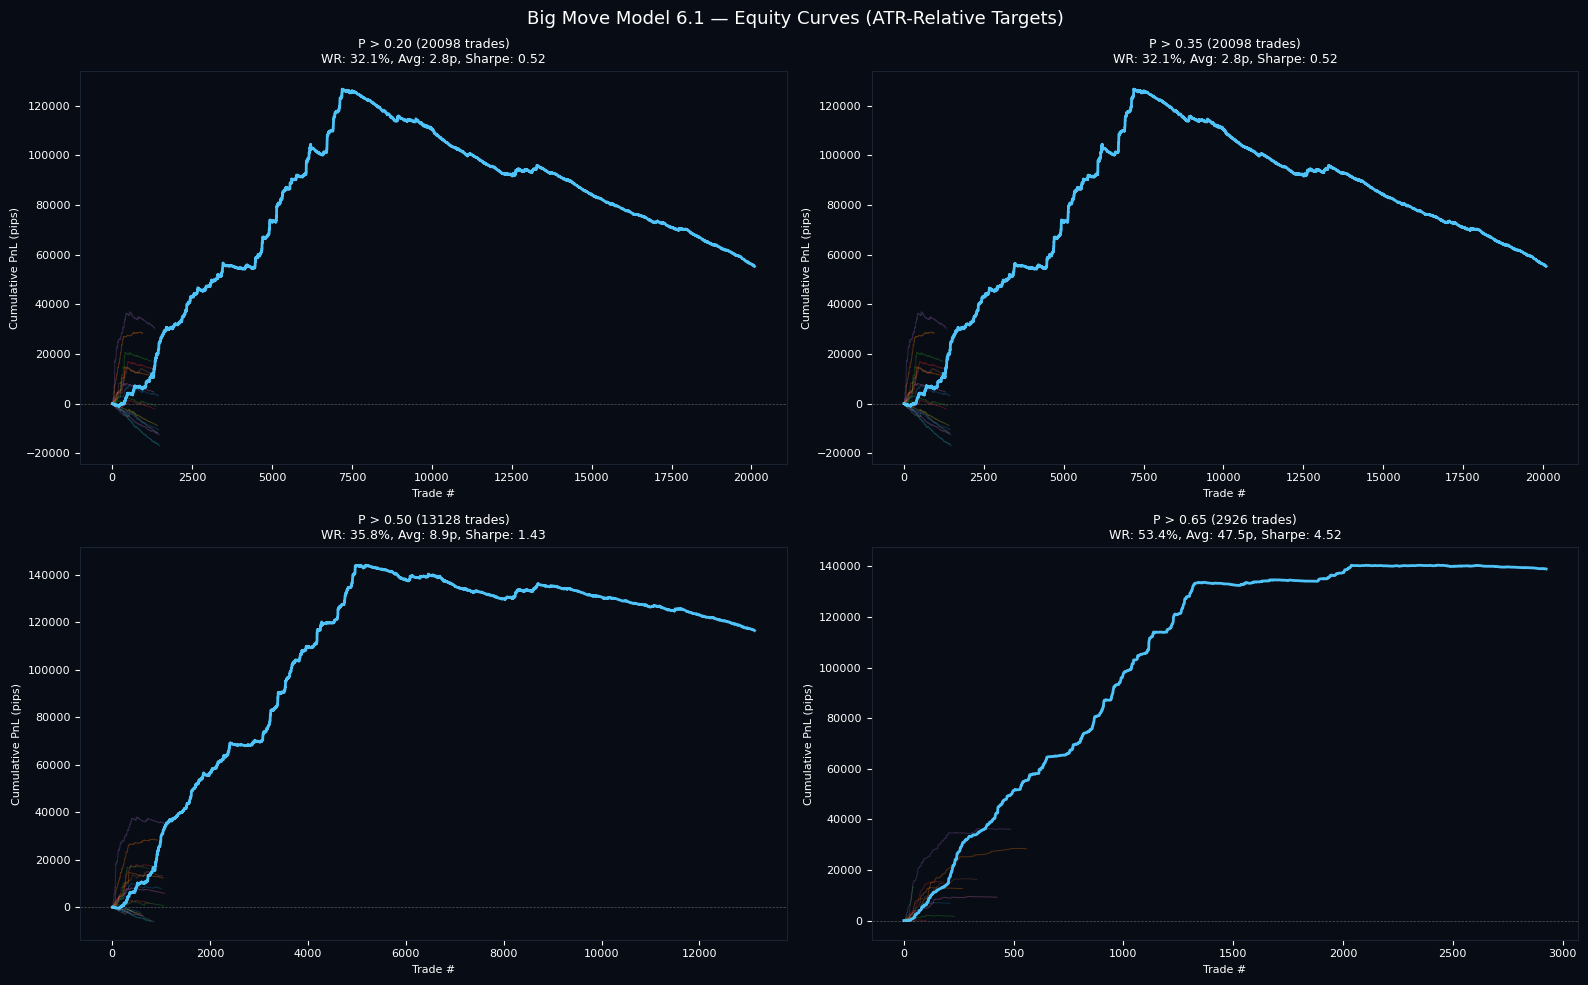

In [9]:
if not backtest_results:
    print('No backtest results — skipping equity curves.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.patch.set_facecolor('#080c14')

    # Pick 4 thresholds to plot
    thresholds_to_plot = sorted(backtest_results.keys())
    if len(thresholds_to_plot) > 4:
        step = len(thresholds_to_plot) // 4
        thresholds_to_plot = thresholds_to_plot[::step][:4]

    for ax, thresh in zip(axes.flatten(), thresholds_to_plot):
        ax.set_facecolor('#080c14')
        ax.tick_params(colors='white', labelsize=8)
        for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
        
        trades = backtest_results[thresh]
        trades_sorted = trades.sort_values('entry_time')
        cum_pnl = trades_sorted['realized_pnl'].cumsum()
        
        # Per-pair equity
        for pair in sorted(trades['pair'].unique()):
            p = trades_sorted[trades_sorted['pair'] == pair]
            pair_cum = p['realized_pnl'].cumsum()
            ax.plot(range(len(pair_cum)), pair_cum.values, alpha=0.3, linewidth=0.7)
        
        # Aggregate equity
        ax.plot(range(len(cum_pnl)), cum_pnl.values, color='#4fc3f7', linewidth=2)
        ax.axhline(0, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
        
        wr = (trades['realized_pnl'] > 0).mean()
        avg = trades['realized_pnl'].mean()
        sharpe = (trades['realized_pnl'].mean() / trades['realized_pnl'].std()) * np.sqrt(252) if trades['realized_pnl'].std() > 0 else 0
        
        title_lines = [
            f'P > {thresh:.2f} ({len(trades)} trades)',
            f'WR: {wr:.1%}, Avg: {avg:.1f}p, Sharpe: {sharpe:.2f}'
        ]
        ax.set_title('\n'.join(title_lines), color='white', fontsize=9)
        ax.set_xlabel('Trade #', color='white', fontsize=8)
        ax.set_ylabel('Cumulative PnL (pips)', color='white', fontsize=8)

    plt.suptitle('Big Move Model 6.1 — Equity Curves (ATR-Relative Targets)', color='white', fontsize=13)
    plt.tight_layout()
    plt.show()

## 9. Save Models + Feature Importance

Saved model_long.joblib (0.7 MB)
Saved model_short.joblib (0.7 MB)


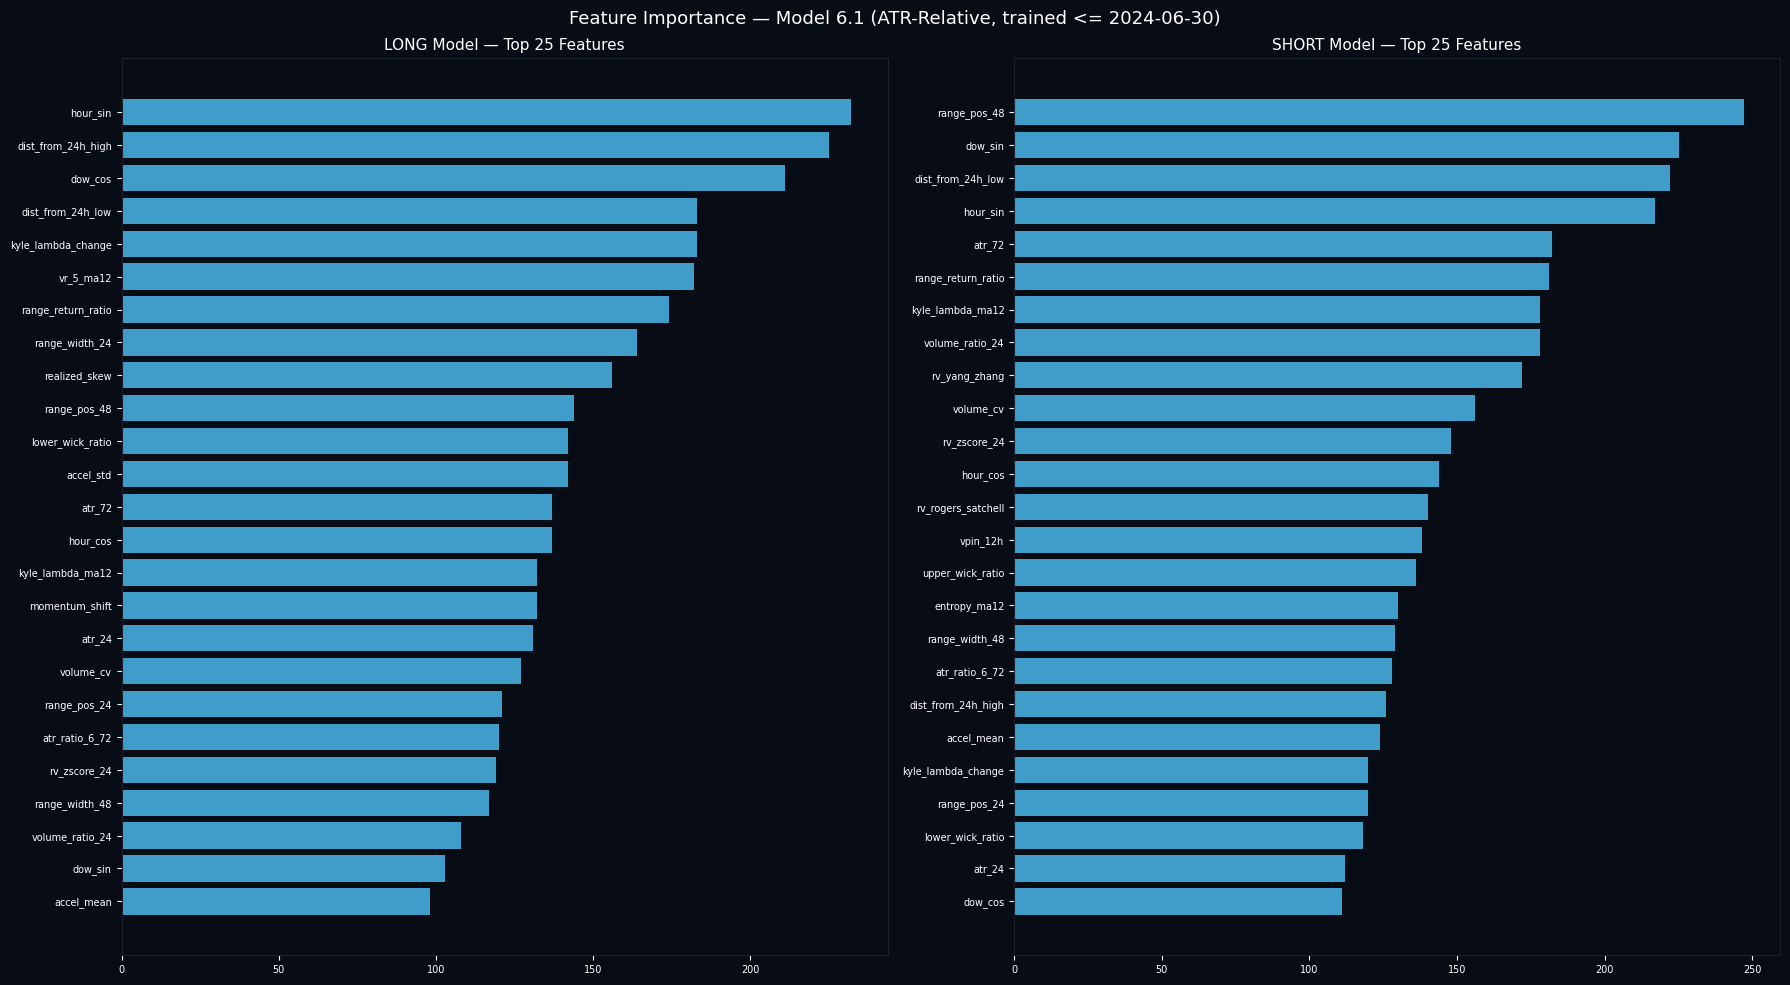

In [10]:
# Save models for live use
joblib.dump({
    'model': model_long,
    'direction': 'long',
    'mfe_atr_multiplier': MFE_ATR_MULTIPLIER,
    'feature_cols': feature_cols,
    'train_end': TRAIN_END,
    'n_iters': n_iters_long,
}, MODELS_DIR / 'model_long.joblib')

joblib.dump({
    'model': model_short,
    'direction': 'short',
    'mfe_atr_multiplier': MFE_ATR_MULTIPLIER,
    'feature_cols': feature_cols,
    'train_end': TRAIN_END,
    'n_iters': n_iters_short,
}, MODELS_DIR / 'model_short.joblib')

print(f'Saved model_long.joblib ({(MODELS_DIR / "model_long.joblib").stat().st_size / 1e6:.1f} MB)')
print(f'Saved model_short.joblib ({(MODELS_DIR / "model_short.joblib").stat().st_size / 1e6:.1f} MB)')

# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor('#080c14')

for ax, (name, model) in zip(axes, [
    ('LONG Model', model_long),
    ('SHORT Model', model_short),
]):
    importance = pd.Series(model.feature_importances_, index=feature_cols)
    importance = importance.sort_values(ascending=True).tail(25)
    
    ax.barh(importance.index, importance.values, color='#4fc3f7', alpha=0.8)
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=7)
    ax.set_title(f'{name} — Top 25 Features', color='white', fontsize=11)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle(f'Feature Importance — Model 6.1 (ATR-Relative, trained <= {TRAIN_END})', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Diagnostics — Probability Calibration

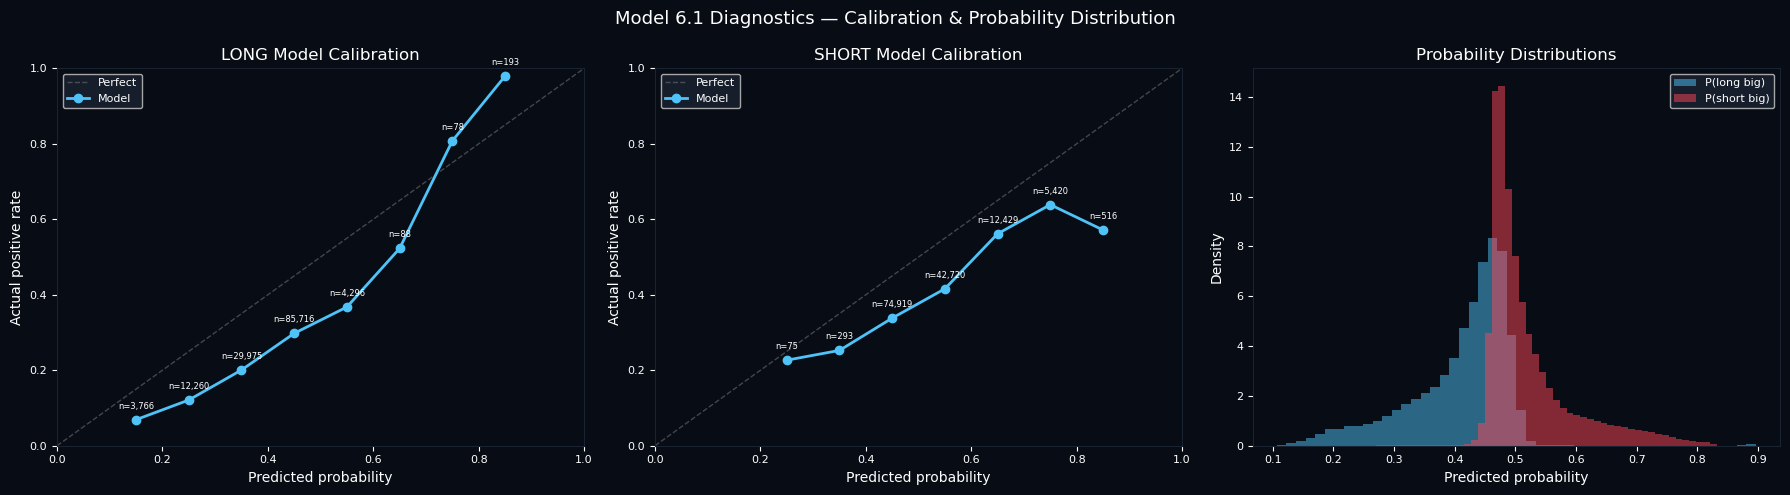

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#080c14')

for ax in axes:
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

for ax_idx, (direction, p_col, t_col) in enumerate([
    ('LONG', 'p_long', 'target_long'),
    ('SHORT', 'p_short', 'target_short')
]):
    bins = np.linspace(0, 1, 11)
    bin_centers = []
    bin_actual = []
    bin_counts = []
    
    for i in range(len(bins) - 1):
        mask = (results[p_col] >= bins[i]) & (results[p_col] < bins[i+1])
        if mask.sum() > 50:
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            bin_actual.append(results.loc[mask, t_col].mean())
            bin_counts.append(mask.sum())
    
    axes[ax_idx].plot([0, 1], [0, 1], '--', color='gray', linewidth=1, alpha=0.5, label='Perfect')
    axes[ax_idx].plot(bin_centers, bin_actual, 'o-', color='#4fc3f7', linewidth=2, markersize=6, label='Model')
    
    for x, y, n in zip(bin_centers, bin_actual, bin_counts):
        axes[ax_idx].annotate(f'n={n:,}', (x, y), textcoords='offset points',
                             xytext=(0, 8), color='white', fontsize=6, ha='center')
    
    axes[ax_idx].set_xlabel('Predicted probability', color='white')
    axes[ax_idx].set_ylabel('Actual positive rate', color='white')
    axes[ax_idx].set_title(f'{direction} Model Calibration', color='white')
    axes[ax_idx].legend(facecolor='#1a2332', labelcolor='white', fontsize=8)
    axes[ax_idx].set_xlim(0, 1); axes[ax_idx].set_ylim(0, 1)

axes[2].hist(results['p_long'], bins=50, alpha=0.5, color='#4fc3f7', label='P(long big)', density=True)
axes[2].hist(results['p_short'], bins=50, alpha=0.5, color='#ff4757', label='P(short big)', density=True)
axes[2].set_xlabel('Predicted probability', color='white')
axes[2].set_ylabel('Density', color='white')
axes[2].set_title('Probability Distributions', color='white')
axes[2].legend(facecolor='#1a2332', labelcolor='white', fontsize=8)

plt.suptitle('Model 6.1 Diagnostics — Calibration & Probability Distribution', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Monthly PnL Breakdown

Monthly PnL (P > 0.55):

     Month   Trades     TotalPnL     AvgPnL     Win%     AvgMFE
--------------------------------------------------------------
   2024-07      404     17236.3p      42.7p   56.4%      81.7p <<<
   2024-08      415     31836.8p      76.7p   59.8%     132.6p <<<
   2024-09      409     18883.2p      46.2p   52.3%      94.4p <<<
   2024-10      416     12514.8p      30.1p   49.5%      71.3p <<<
   2024-11      350     32855.2p      93.9p   51.7%     142.0p <<<
   2024-12      367     18664.3p      50.9p   51.8%     108.4p <<<
   2025-01      362     24399.2p      67.4p   52.5%     112.8p <<<
   2025-02      333      -601.2p      -1.8p   31.8%      34.9p
   2025-03      371      2430.7p       6.6p   38.5%      47.4p <<<
   2025-04      266       -18.7p      -0.1p   38.0%      51.7p
   2025-05      319     -1245.5p      -3.9p   34.2%      32.3p
   2025-06      337      5491.8p      16.3p   46.3%      54.3p <<<
   2025-07      336      2291.6p       6.8p   39.0%     

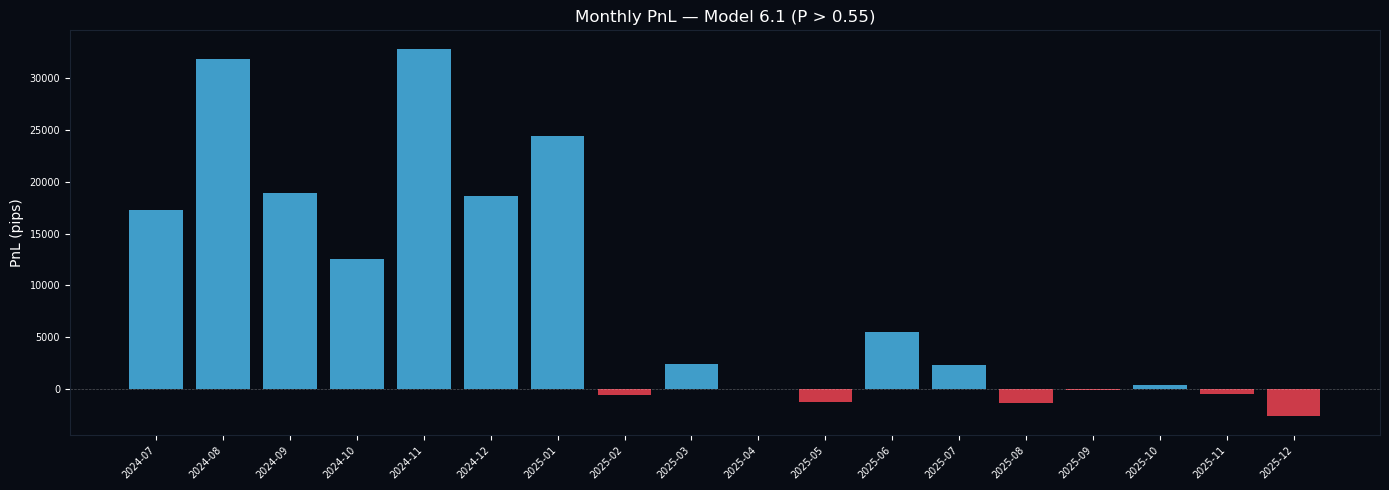


Positive months: 11 / 18 (61%)
Best month:  32855.2 pips
Worst month: -2662.7 pips


In [12]:
if best_trades is None or len(best_trades) == 0:
    print('No trades — skipping monthly PnL.')
else:
    trades = best_trades.copy()
    trades['month'] = pd.to_datetime(trades['entry_time']).dt.to_period('M')

    monthly = trades.groupby('month').agg(
        trades=('realized_pnl', 'count'),
        total_pnl=('realized_pnl', 'sum'),
        avg_pnl=('realized_pnl', 'mean'),
        win_rate=('realized_pnl', lambda x: (x > 0).mean()),
        avg_mfe=('mfe_pips', 'mean'),
    )

    print(f'Monthly PnL (P > {best_thresh:.2f}):\n')
    print(f'{"Month":>10} {"Trades":>8} {"TotalPnL":>12} {"AvgPnL":>10} {"Win%":>8} {"AvgMFE":>10}')
    print('-' * 62)
    for idx, row in monthly.iterrows():
        flag = ' <<<' if row['total_pnl'] > 0 else ''
        print(f'{str(idx):>10} {row["trades"]:>8.0f} {row["total_pnl"]:>11.1f}p {row["avg_pnl"]:>9.1f}p '
              f'{row["win_rate"]:>7.1%} {row["avg_mfe"]:>9.1f}p{flag}')

    # Monthly PnL bar chart
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor('#080c14')
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=7)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

    colors = ['#4fc3f7' if v > 0 else '#ff4757' for v in monthly['total_pnl']]
    ax.bar(range(len(monthly)), monthly['total_pnl'].values, color=colors, alpha=0.8)
    ax.set_xticks(range(len(monthly)))
    ax.set_xticklabels([str(m) for m in monthly.index], rotation=45, ha='right', color='white', fontsize=7)
    ax.axhline(0, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
    ax.set_title(f'Monthly PnL — Model 6.1 (P > {best_thresh:.2f})', color='white')
    ax.set_ylabel('PnL (pips)', color='white')
    plt.tight_layout()
    plt.show()

    pos_months = (monthly['total_pnl'] > 0).sum()
    neg_months = (monthly['total_pnl'] <= 0).sum()
    print(f'\nPositive months: {pos_months} / {len(monthly)} ({100*pos_months/len(monthly):.0f}%)')
    print(f'Best month:  {monthly["total_pnl"].max():.1f} pips')
    print(f'Worst month: {monthly["total_pnl"].min():.1f} pips')

## 12. Summary

In [13]:
print('=' * 70)
print('BIG MOVE MODEL 6.1 — TRAINING COMPLETE (ATR-Relative Targets)')
print('=' * 70)

print(f'\nModels saved to: {MODELS_DIR.resolve()}')
for f in sorted(MODELS_DIR.glob('*.joblib')):
    print(f'  {f.name:<25} {f.stat().st_size / 1e6:.1f} MB')

print(f'\n-- CV Results --')
print(f'  LONG:  AUC={np.mean(cv_auc_long):.4f}, logloss={np.mean(cv_logloss_long):.4f}, iters={best_iters_long}')
print(f'  SHORT: AUC={np.mean(cv_auc_short):.4f}, logloss={np.mean(cv_logloss_short):.4f}, iters={best_iters_short}')

print(f'\n-- Test Set Results (UNSEEN, after {TRAIN_END}) --')
print(f'  LONG AUC:  {auc_long:.4f}')
print(f'  SHORT AUC: {auc_short:.4f}')

if best_thresh is not None and len(best_trades) > 0:
    print(f'\n-- Best Backtest Config --')
    print(f'  Threshold: P > {best_thresh:.2f}')
    print(f'  Trades: {len(best_trades)}')
    wr = (best_trades['realized_pnl'] > 0).mean()
    avg = best_trades['realized_pnl'].mean()
    total = best_trades['realized_pnl'].sum()
    sharpe = (best_trades['realized_pnl'].mean() / best_trades['realized_pnl'].std()) * np.sqrt(252) if best_trades['realized_pnl'].std() > 0 else 0
    print(f'  Win rate: {wr:.1%}')
    print(f'  Avg PnL/trade: {avg:.1f} pips')
    print(f'  Total PnL: {total:.1f} pips')
    print(f'  Sharpe: {sharpe:.2f}')
    print(f'  Avg MFE when triggered: {best_trades["mfe_pips"].mean():.1f} pips')
    print(f'  Avg trail stop: {best_trades["trail_stop_pips"].mean():.1f} pips')
else:
    print(f'\n-- Backtest: no trades at any threshold --')

print(f'\n-- Config --')
print(f'  MFE threshold: {MFE_ATR_MULTIPLIER}x ATR_24')
print(f'  Features: {len(feature_cols)}')
print(f'  Training cutoff: {TRAIN_END}')
print(f'  Test period: {results.index.min().date()} -> {results.index.max().date()}')
print(f'  Pairs: {len(ALL_PAIRS)}')

BIG MOVE MODEL 6.1 — TRAINING COMPLETE (ATR-Relative Targets)

Models saved to: C:\Users\noual\lumeny\backend\models_6.1
  model_long.joblib         0.7 MB
  model_short.joblib        0.7 MB

-- CV Results --
  LONG:  AUC=0.5550, logloss=0.6244, iters=[4, 5, 5, 4, 5]
  SHORT: AUC=0.5506, logloss=0.6426, iters=[5, 5, 5, 5, 5]

-- Test Set Results (UNSEEN, after 2024-06-30) --
  LONG AUC:  0.6101
  SHORT AUC: 0.5924

-- Best Backtest Config --
  Threshold: P > 0.55
  Trades: 6543
  Win rate: 43.2%
  Avg PnL/trade: 24.5 pips
  Total PnL: 160551.3 pips
  Sharpe: 2.92
  Avg MFE when triggered: 65.2 pips
  Avg trail stop: 37.8 pips

-- Config --
  MFE threshold: 1.5x ATR_24
  Features: 112
  Training cutoff: 2024-06-30
  Test period: 2024-07-01 -> 2025-12-31
  Pairs: 15
